# Exercise 4.10_Part_1.2_Step: 5 to 10

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [5]:
# Creating path to use for reaching the desired folders
path='/home/haus/DA_Course_CF/Exercise_4_Instacart_Basket_Analysis'

In [8]:
# Creating an output path for the folder Visualzations
output_fvi = '/home/haus/DA_Course_CF/Exercise_4_Instacart_Basket_Analysis/04_Analysis/Visualizations'

In [10]:
# Creating an output path for the folder Prepared Data
output_fpd = '/home/haus/DA_Course_CF/Exercise_4_Instacart_Basket_Analysis/02_Data/Prepared_Data'

In [12]:
# Importing last data-frame activity_customers_full
df_copm2=pd.read_pickle(r'/home/haus/DA_Course_CF/Exercise_4_Instacart_Basket_Analysis/02_Data/Prepared_Data/activity_customers_full.pkl')

In [13]:
df_copm2.info

<bound method DataFrame.info of           order_id  user_id eval_set  order_number  order_dow  \
0          2539329        1    prior             1          2   
1          2539329        1    prior             1          2   
2          2539329        1    prior             1          2   
3          2539329        1    prior             1          2   
4          2539329        1    prior             1          2   
...            ...      ...      ...           ...        ...   
32404854   2977660   206209    prior            13          1   
32404855   2977660   206209    prior            13          1   
32404856   2977660   206209    prior            13          1   
32404857   2977660   206209    prior            13          1   
32404858   2977660   206209    prior            13          1   

          order_hour_of_day  days_since_prior_order  first_order  product_id  \
0                         8                     NaN         True         196   
1                         8

In [16]:
df_copm2.columns

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'first_order',
       'product_id', 'add_to_cart_order', 'reordered', 'Unnamed: 0_y',
       'product_name', 'aisle_id', 'department_id', 'prices', 'merge_info',
       'price_range_loc', 'busiest_day', 'Busiest_days',
       'busiest_period_of_day', 'max_order', 'loyalty_flag', 'average_spend',
       'spending_flag', 'Customer_frequency', 'frequency_flag', 'gender',
       'state', 'age', 'date_joined', 'n_dependants', 'marital_status',
       'income', 'State Code', 'Region', 'Division', 'low_activity_flag'],
      dtype='object')

In [18]:
# Checking the imported data-frame
df_copm2.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,first_order,product_id,add_to_cart_order,...,state,age,date_joined,n_dependants,marital_status,income,State Code,Region,Division,low_activity_flag
0,2539329,1,prior,1,2,8,NaN,True,196,1,...,Alabama,31,2/17/2019,3,married,40423,AL,South,East South Central,1
1,2539329,1,prior,1,2,8,NaN,True,14084,2,...,Alabama,31,2/17/2019,3,married,40423,AL,South,East South Central,1
2,2539329,1,prior,1,2,8,NaN,True,12427,3,...,Alabama,31,2/17/2019,3,married,40423,AL,South,East South Central,1
3,2539329,1,prior,1,2,8,NaN,True,26088,4,...,Alabama,31,2/17/2019,3,married,40423,AL,South,East South Central,1
4,2539329,1,prior,1,2,8,NaN,True,26405,5,...,Alabama,31,2/17/2019,3,married,40423,AL,South,East South Central,1


Note: Activity flag: "1"=Low-activity customer (< 5 orders) / "0"=High-activity customer (>5 orders)

Step 5 - The marketing and business strategy units at Instacart want to create more-relevant marketing strategies for different products and are, thus, curious about customer profiling in their database. Create a profiling variable based on age, income, certain goods in the “department_id” column, and number of dependents. You might also use the “orders_day_of_week” and “order_hour_of_day” columns if you can think of a way they would impact customer profiles. (Hint: As an example, try thinking of what characteristics would lead you to the profile “Single adult” or “Young parent.”)

1 Check the basic statistics for our profiling variables

In [28]:
# Age Statistics
print("Age statistics:")
print(df_copm2['age'].describe())

Age statistics:
count    32404859.0
mean       49.46527
std       18.485581
min            18.0
25%            33.0
50%            49.0
75%            65.0
max            81.0
Name: age, dtype: Float64


In [30]:
# Income statistics
print("\nIncome statistics:")
print(df_copm2['income'].describe())


Income statistics:
count      32404859.0
mean     99437.733295
std      43057.272542
min           25903.0
25%           67004.0
50%           96618.0
75%          127912.0
max          593901.0
Name: income, dtype: Float64


In [32]:
# Number of dependants
print("\nNumber of dependents distribution:")
print(df_copm2['n_dependants'].value_counts())


Number of dependents distribution:
n_dependants
3    8135109
0    8097503
2    8091143
1    8081104
Name: count, dtype: Int64


In [34]:
# Marital status distribution
print("\nMarital status distribution:")
print(df_copm2['marital_status'].value_counts())


Marital status distribution:
marital_status
married                             22756753
single                               5325691
divorced/widowed                     2771812
living with parents and siblings     1550603
Name: count, dtype: int64


In [36]:
# Check the distribution of department_id
print("\nDepartment ID distribution:")
print(df_copm2['department_id'].value_counts())


Department ID distribution:
department_id
4     9479291
16    5398747
19    2887550
7     2688123
1     2234743
13    1875369
3     1172428
15    1068058
20    1051249
9      866627
17     738666
12     708927
14     703033
11     447572
18     423802
6      269253
5      153696
8       97716
21      69145
2       36291
10      34573
Name: count, dtype: int64


In [43]:
# Check order day of week distributions
print("\nOrder day of week distribution:")
print(df_copm2['order_dow'].value_counts())


Order day of week distribution:
order_dow
0    6204182
1    5660230
6    4496490
2    4213830
5    4205791
3    3840534
4    3783802
Name: count, dtype: int64


In [45]:
# Check order day of week and hour of day distributions
print("\nOrder hour of day distribution:")
print(df_copm2['order_hour_of_day'].value_counts().sort_index())


Order hour of day distribution:
order_hour_of_day
0      218769
1      115700
2       69375
3       51281
4       53242
5       87961
6      290493
7      891054
8     1718118
9     2454203
10    2761760
11    2736140
12    2618532
13    2660954
14    2689136
15    2662144
16    2535202
17    2087654
18    1636502
19    1258305
20     976156
21     795637
22     634225
23     402316
Name: count, dtype: int64


In [49]:
# Create a copy of the original data-frame to avoid modifying it directly
df=df_copm2.copy()

Create Customer Profile Variables.
I will create new columns in the data-frame to represent age group, income group, dependents group, and department profile. 

In [51]:
# 1. Create age group
def age_group(age):
    if age < 25:
        return 'Young Adult'
    elif age < 40:
        return 'Adult'
    elif age < 60:
        return 'Middle Aged'
    else:
        return 'Senior'
df['age_group'] = df['age'].apply(age_group)

In [53]:
# 2. Create income group
def income_group(income):
    if income < 50000:
        return 'Low Income'
    elif income < 100000:
        return 'Lower Middle Income'
    elif income < 200000:
        return 'Upper Middle Income'
    else:
        return 'High Income'
df['income_group'] = df['income'].apply(income_group)

In [55]:
# 3. Create dependents group
def dependents_group(n):
    if n == 0:
        return 'No Dependents'
    elif n == 1:
        return 'One Dependent'
    else:
        return 'Multiple Dependents'
df['dependents_group'] = df['n_dependants'].apply(dependents_group)

In [57]:
# 4. Department profile (babies=18, personal care=11, alcohol=5)
def department_profile(dept):
    if dept == 18:
        return 'Babies'
    elif dept == 11:
        return 'Personal Care'
    elif dept == 5:
        return 'Alcohol'
    else:
        return 'Other'
df['department_profile'] = df['department_id'].apply(department_profile)

In [59]:
# 5. Combine into customer profile
def customer_profile(row):
    if row['dependents_group'] == 'No Dependents' and row['age_group'] == 'Young Adult':
        return 'Young Adult Single'
    elif row['dependents_group'] != 'No Dependents' and row['department_profile'] == 'Babies':
        return 'Young Parent'
    elif row['dependents_group'] == 'No Dependents' and row['age_group'] == 'Senior':
        return 'Senior Single'
    elif row['department_profile'] == 'Alcohol':
        return 'Social Adult'
    else:
        return 'General Family'
df['customer_profile'] = df.apply(customer_profile, axis=1)

Assign one profile per User. Ensure that each user has only one profile, prioritizing more specific types (e.g., if a user is ever a "Young Parent," they are always a "Young Parent").

The data-frame (df_copm2) has a "user_id" column. I got an error because "user_id" is both a column and an index name. I want to group by "user_id" to assign customer profiles, and keep "user_id" as a column for further analysis. So I need to 1) Rename the index if its name is "user_id". 2) Reset the index to move it into a column with a new name (e.g., "user_id_index"). 3) Proceed with your groupby and profiling using the column "user_id".

In [77]:
# Step 1: Remove ambiguity if 'user_id' is in the index
if 'user_id' in df.index.names:
    current_names = list(df.index.names)
    new_names = ['user_id_index' if name == 'user_id' else name for name in current_names]
    df = df.rename_axis(new_names)
    df = df.reset_index()

In [79]:
# Set profile priority
profile_priority = ['Young Adult Single', 'Young Parent', 'Senior Single', 'Social Adult', 'General Family']

def assign_profile(group):
    for profile in profile_priority:
        if profile in group['customer_profile'].values:
            group['customer_profile'] = profile
            return group
    return group

df = df.groupby('user_id').apply(assign_profile, include_groups=False)

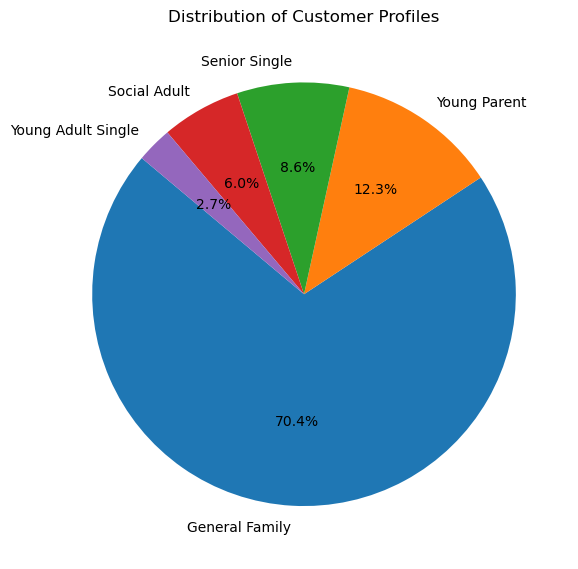

In [85]:
# Create a Pie Chart: Distribution of Customer Profiles
profile_counts = df[['user_id_index', 'customer_profile']].drop_duplicates()['customer_profile'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(profile_counts, labels=profile_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Customer Profiles')
plt.tight_layout()
plt.savefig(f'{output_fvi}/customer_profile_pie.png')
plt.show()

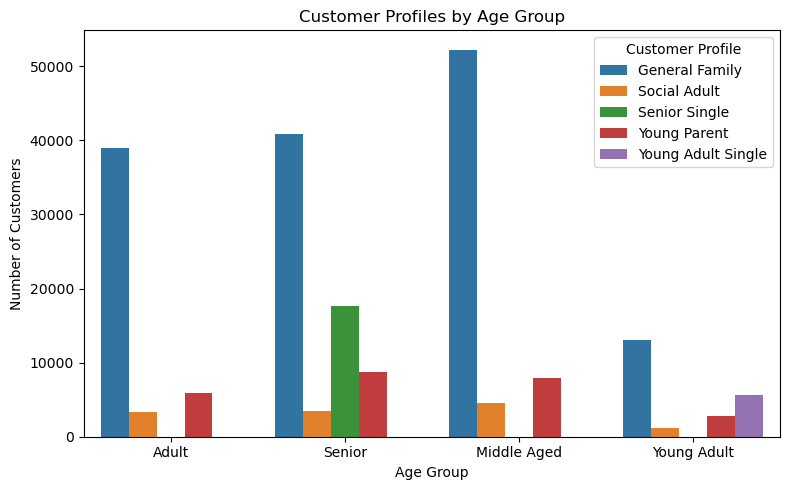

In [87]:
# Bar Chart: Customer Profiles by Age Group
age_profile = df[['user_id_index', 'age_group', 'customer_profile']].drop_duplicates()
plt.figure(figsize=(8,5))
sns.countplot(data=age_profile, x='age_group', hue='customer_profile')
plt.title('Customer Profiles by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.legend(title='Customer Profile')
plt.tight_layout()
plt.savefig(f'{output_fvi}/age_profile_bar.png')
plt.show()

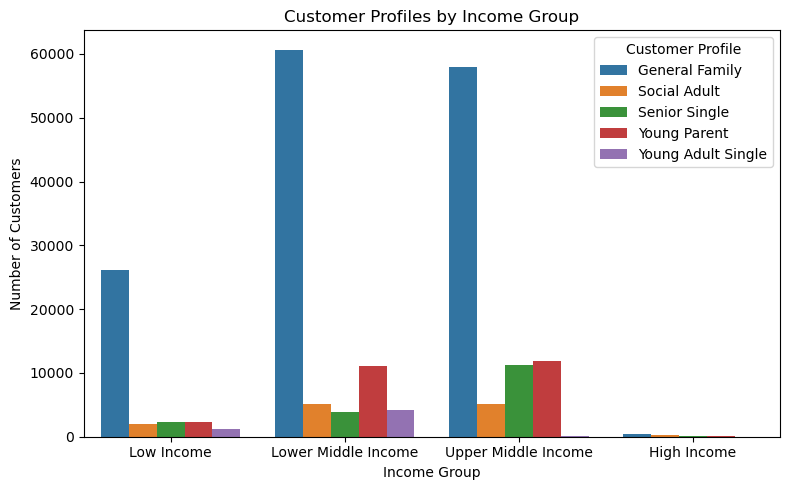

In [89]:
# Bar Chart: Customer Profiles by Income Group
income_profile = df[['user_id_index', 'income_group', 'customer_profile']].drop_duplicates()
plt.figure(figsize=(8,5))
sns.countplot(data=income_profile, x='income_group', hue='customer_profile')
plt.title('Customer Profiles by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.legend(title='Customer Profile')
plt.tight_layout()
plt.savefig(f'{output_fvi}/income_profile_bar.png')
plt.show()

Step 7 - Aggregate the max, mean, and min variables on a customer-profile level for usage frequency and expenditure.

Note: to aggregate customer profile data for frequency and spending metrics, I will use the existing data-frame copy.

In [96]:
# Step 1: Aggregate max, mean, min for frequency and expenditure by customer_profile
agg_profile = df.groupby('customer_profile').agg(
    frequency_max=('Customer_frequency', 'max'),
    frequency_mean=('Customer_frequency', 'mean'),
    frequency_min=('Customer_frequency', 'min'),
    spend_max=('average_spend', 'max'),
    spend_mean=('average_spend', 'mean'),
    spend_min=('average_spend', 'min')
).reset_index()

In [98]:
# Step 2: Show results
print("Customer Profile Metrics:")
display(agg_profile)

Customer Profile Metrics:


,customer_profile,frequency_max,frequency_mean,frequency_min,spend_max,spend_mean,spend_min
0,General Family,30.0,11.129379,0.0,23.200000,7.775767,1.000
1,Senior Single,30.0,10.315293,0.0,16.931250,7.800859,1.200
2,Social Adult,30.0,10.379216,0.0,13.800000,7.774930,1.300
3,Young Adult Single,30.0,10.565061,0.0,16.700000,7.776214,1.100
4,Young Parent,30.0,8.500176,0.0,15.706667,7.832116,1.425


In [100]:
# Step 3: Export to CSV (optional)
agg_profile.to_csv(f'{output_fpd}/customer_profile_metrics.csv', index=False)

Step 8 / 9: Compare your customer profiles with regions and departments. Can you identify a link between them? Customers may demonstrate different behaviors across regions, which could make this information important. Produce suitable charts to illustrate your results and export them in your project folder.

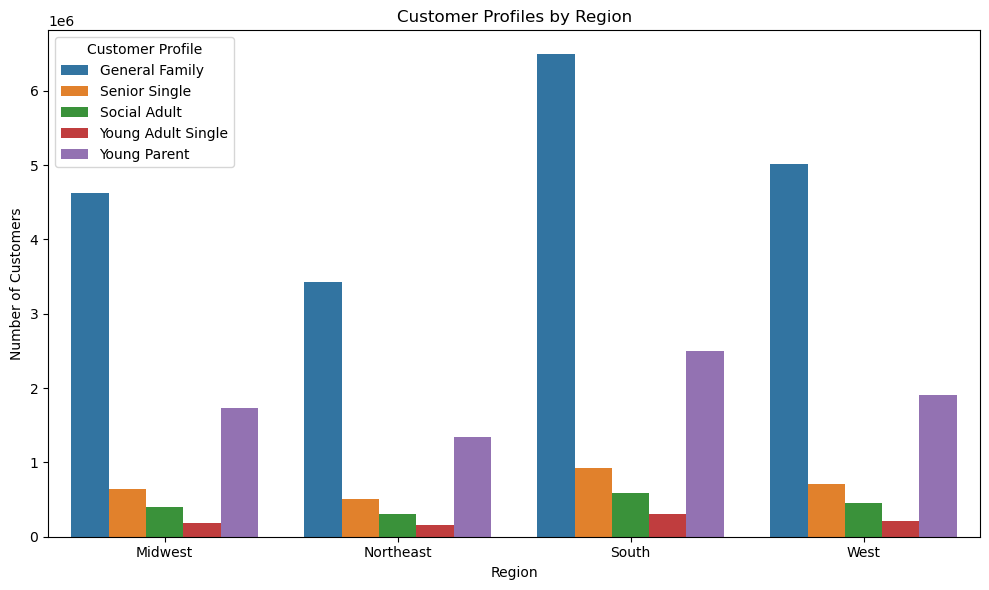

In [106]:
# Aggregate counts of customer profiles by region
profile_region_counts = df.groupby(['Region', 'customer_profile'], observed=True).size().reset_index(name='count')

plt.figure(figsize=(10,6))
sns.barplot(data=profile_region_counts, x='Region', y='count', hue='customer_profile')
plt.title('Customer Profiles by Region')
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.legend(title='Customer Profile')
plt.tight_layout()
plt.savefig(f'{output_fvi}/customer_profiles_by_region.png')
plt.show()

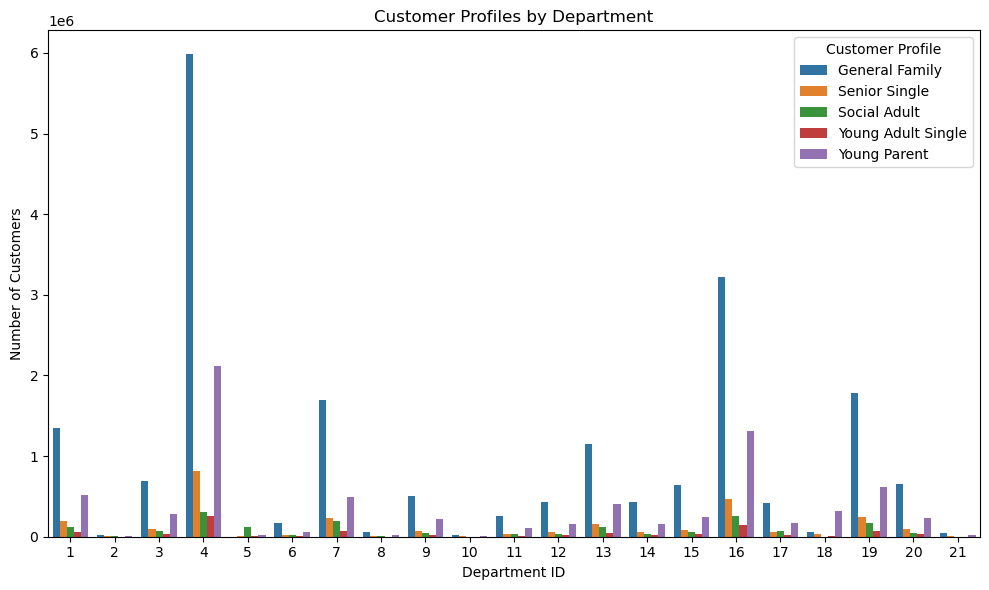

In [108]:
# Aggregate counts of customer profiles by department
profile_dept_counts = df.groupby(['department_id', 'customer_profile'], observed=True).size().reset_index(name='count')

plt.figure(figsize=(10,6))
sns.barplot(data=profile_dept_counts, x='department_id', y='count', hue='customer_profile')
plt.title('Customer Profiles by Department')
plt.xlabel('Department ID')
plt.ylabel('Number of Customers')
plt.legend(title='Customer Profile')
plt.tight_layout()
plt.savefig(f'{output_fvi}/customer_profiles_by_department.png')
plt.show()

Step 10 - Tidy up your script, export your final data set, and save your notebook.

Tidy up the data-frame "df" (copy of the original data-frame (df_copm2)

In [114]:
# List of columns to keep
relevant_columns = [
    'user_id', 'customer_profile', 'age', 'age_group', 'income', 'income_group',
    'n_dependants', 'dependents_group', 'department_id', 'department_profile',
    'Region', 'Customer_frequency', 'average_spend'
]

In [116]:
# Only keep columns that exist in df
final_columns = [col for col in relevant_columns if col in df.columns]
final_df = df[final_columns].drop_duplicates()

In [124]:
# Export to pickle
final_df.to_pickle(os.path.join(output_fpd, 'final_customer_profiles.pkl'))
print(f"Final dataset exported to: {output_fpd}")

Final dataset exported to: /home/haus/DA_Course_CF/Exercise_4_Instacart_Basket_Analysis/02_Data/Prepared_Data


# Close Part 1.2